In [50]:
!pip -q install mitsuba

In [51]:
import mitsuba as mi
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

mi.set_variant('cuda_ad_spectral')

In [58]:
def transform_scene_per_object(input_file, output_file, sensor_bands, objects_data):

    tree = ET.parse(input_file)
    root = tree.getroot()

    integrator = root.find("integrator")
    integrator.set("type", "path")
    integrator.find("integer").set("value", "16")

    sensor = root.find("sensor")
    sampler = sensor.find("sampler")
    sampler.set("type", "multijitter")

    film = sensor.find("film")
    film.set("type", "specfilm")

    for child in list(film):
        film.remove(child)

    ET.SubElement(film, "integer", {"name": "width", "value": "1920"})
    ET.SubElement(film, "integer", {"name": "height", "value": "1080"})

    for wl in sensor_bands:
        band = ET.SubElement(film, "spectrum", {"type": "regular", "name": f"band_{int(wl)}"})
        ET.SubElement(band, "string", {"name": "values", "value": "1.0, 1.0"})
        ET.SubElement(band, "float", {"name": "wavelength_min", "value": str(wl)})
        ET.SubElement(band, "float", {"name": "wavelength_max", "value": str(wl + 1)})

    rfilter = ET.SubElement(film, "rfilter", {"type": "gaussian"})
    ET.SubElement(rfilter, "float", {"name": "stddev", "value": "0.5"})

    for shape in root.findall("shape"):
        shape_id = shape.get("id")

        if shape_id not in objects_data:
            continue

        data = objects_data[shape_id]

        for ref in shape.findall("ref"):
            shape.remove(ref)
        for bsdf in shape.findall("bsdf"):
            shape.remove(bsdf)

        emitter = ET.SubElement(shape, "emitter", {"type": "area"})
        spectrum_r = ET.SubElement(emitter, "spectrum", {"type": "irregular", "name": "radiance"})
        ET.SubElement(spectrum_r, "string", {"name": "wavelengths", "value": ",".join(map(str, data["wavelengths"]))})
        ET.SubElement(spectrum_r, "string", {"name": "values", "value": ",".join(map(str, data["radiance"]))})

        bsdf = ET.SubElement(shape, "bsdf", {"type": "diffuse"})
        spectrum_refl = ET.SubElement(bsdf, "spectrum", {"type": "irregular", "name": "reflectance"})
        ET.SubElement(spectrum_refl, "string", {"name": "wavelengths", "value": ",".join(map(str, data["wavelengths"]))})
        ET.SubElement(spectrum_refl, "string", {"name": "values", "value": ",".join(map(str, data["reflectance"]))})

    tree.write(output_file, encoding="utf-8", xml_declaration=True)


n = 10
sensor_bands = np.linspace(8000, 10000, n)
objects_data = {
    "elm__2": {
        "wavelengths": sensor_bands,
        "radiance": [300]*n,
        "reflectance": [0.0001]*n
    },
    "elm__6": {
        "wavelengths": sensor_bands,
        "radiance": [250]*n,
        "reflectance": [0.0001]*n
    },
    "elm__7": {
        "wavelengths": sensor_bands,
        "radiance": [500]*n,
        "reflectance": [0.0001]*n
    },
    "elm__8": {
        "wavelengths": sensor_bands,
        "radiance": [700]*n,
        "reflectance": [0.0001]*n
    },
    "elm__9": {
        "wavelengths": sensor_bands,
        "radiance":  [800]*n,
        "reflectance": [0.0001]*n
    },
    "elm__10": {
        "wavelengths": sensor_bands,
        "radiance": [300]*n,
        "reflectance": [0.0001]*n
    },
    "elm__11": {
        "wavelengths": sensor_bands,
        "radiance": [100]*n,
        "reflectance": [0.0001]*n
    }
}


transform_scene_per_object("scene.xml", "output_scene.xml", sensor_bands, objects_data)


In [59]:
scene = mi.load_file('output_scene.xml')
image = mi.render(scene, spp=512)
image.shape

(1080, 1920, 10)

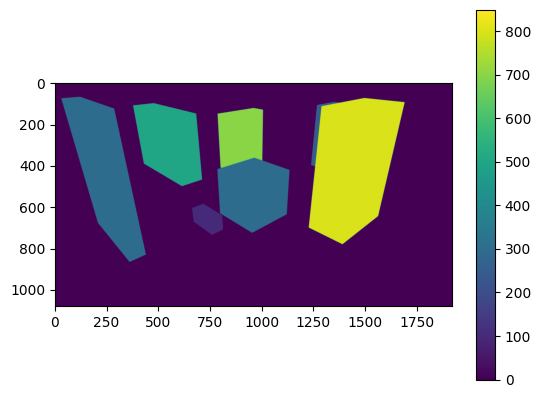

In [60]:
plt.imshow(image[:,:,0])
plt.colorbar()

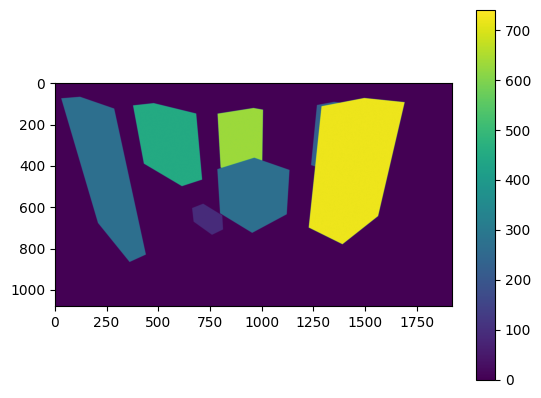

In [61]:
import numpy as np
plt.imshow(np.array(image).mean(axis=2))
plt.colorbar()

In [56]:
[100]*4

[100, 100, 100, 100]